# Segmentador de Etiquetas — Produtos Avícolas
Pipeline 100% clássico com OpenCV. Sem OCR, sem redes neurais.

**Fluxo:**
1. Define caminhos
2. Instala dependências
3. Imports
4. Configurações
5. Funções do pipeline
6. Teste em 1 imagem (etapa a etapa)
7. Processa o dataset completo
8. Visualiza crops gerados

## 1. Caminhos locais
As pastas `Train_and_Validation/` e `resultado/` ficam na mesma pasta deste notebook.

In [73]:
import os

BASE_DIR    = os.path.dirname(os.path.abspath('__file__'))
INPUT_ROOT  = os.path.join(BASE_DIR, 'Train_and_Validation')
OUTPUT_ROOT = os.path.join(BASE_DIR, 'resultado')

print('Dataset :', INPUT_ROOT)
print('Saída   :', OUTPUT_ROOT)

Dataset : e:\Users\Downloads\pdi-trabalho\Train_and_Validation
Saída   : e:\Users\Downloads\pdi-trabalho\resultado


## 2. Instalar dependências

In [74]:
%pip install -q opencv-python numpy matplotlib ipykernel

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 3. Imports

In [75]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 4. Configurações
Ajuste os parâmetros aqui sem precisar mexer no restante do código.

In [114]:
CFG = {
    # 1. Contraste — CLAHE no canal L (LAB)
    "clahe_clip": 3.0,
    "clahe_grid": (8, 8),

    # 2. Suavização — mediana pequena remove ruído de câmera industrial
    "median_ksize": 7,

    # 3. Offset do limiar Otsu
    # Otsu neste dataset escolhe ~116-125; mediana do rótulo escuro ~95
    # Negativo: abaixa o limiar → aceita pixels mais claros → mais área na máscara
    # Positivo: sobe o limiar → exige pixels mais escuros → só o núcleo do rótulo
    "thresh_offset": 0,
#    "thresh_offset": -50,

    # 4. ROI — descarta bordas da imagem (esteira, paredes laterais)
    "roi_left":  0.30,
    "roi_right": 0.90,
    "roi_top":   0.05,
    "roi_bot":   0.95,

    # 5. Morfologia
    # Close: deve preencher apenas os gaps internos do texto (~20-40px entre letras)
    # sem alcançar rótulos vizinhos. Reduzido de (70,50) que fundia tudo.
    # Open: remove manchas menores que o kernel sem destruir o rótulo principal.
    "morph_close_ksize": (20, 15),
    "morph_open_ksize":  (9, 9),

    # 6. Filtros geométricos
    "min_area":       12000,
    "max_area_ratio": 0.55,
    "min_aspect":     0.35,
    "max_aspect":     0.90,
    "min_height_px":  150,
    "min_solidity":   0.55,
    "padding":        15,

    # 7. NMS — elimina detecções duplicadas sobrepostas
    "nms_iou_thresh": 0.45,
}

## 5. Funções do Pipeline

In [115]:
def ler_imagem(caminho):
    img = cv2.imread(caminho)
    if img is None:
        raise FileNotFoundError("Nao foi possivel abrir: " + caminho)
    return img


def extrair_brilho(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, _, _ = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=CFG["clahe_clip"], tileGridSize=CFG["clahe_grid"])
    return clahe.apply(l)


def suavizar(canal):
    return cv2.medianBlur(canal, CFG["median_ksize"])


def binarizar(canal):
    limiar_otsu, _ = cv2.threshold(canal, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    limiar_final = int(limiar_otsu) + CFG["thresh_offset"]
    limiar_final = max(1, min(254, limiar_final))
    _, binaria = cv2.threshold(canal, limiar_final, 255, cv2.THRESH_BINARY_INV)
    return binaria


def aplicar_roi(mascara, img_shape):
    h, w = img_shape[:2]
    roi = np.zeros_like(mascara)
    roi[int(h*CFG["roi_top"]):int(h*CFG["roi_bot"]),
        int(w*CFG["roi_left"]):int(w*CFG["roi_right"])] = 255
    return cv2.bitwise_and(mascara, roi)


def morfologia(mascara):
    k_close = cv2.getStructuringElement(cv2.MORPH_RECT, CFG["morph_close_ksize"])
    k_open  = cv2.getStructuringElement(cv2.MORPH_RECT, CFG["morph_open_ksize"])
    m = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, k_close)
    m = cv2.morphologyEx(m,       cv2.MORPH_OPEN,  k_open)
    return m


def classificar_regioes(mascara, img_shape):
    """Retorna (aceitos, rejeitados_com_motivo) — todos os blobs encontrados."""
    h_total, w_total = img_shape[:2]
    area_total = h_total * w_total
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    aceitos    = []
    rejeitados = []
    for cnt in contornos:
        x, y, w, h = cv2.boundingRect(cnt)
        if h == 0 or w == 0:
            continue
        area_bbox = w * h
        area_cnt  = cv2.contourArea(cnt)
        aspect    = w / h
        hull      = cv2.convexHull(cnt)
        area_hull = cv2.contourArea(hull)
        solidity  = area_cnt / area_hull if area_hull > 0 else 0
        motivo = None
        if   area_bbox < CFG["min_area"]:                    motivo = "area<" + str(CFG["min_area"])
        elif area_bbox > area_total * CFG["max_area_ratio"]: motivo = "area>" + str(int(CFG["max_area_ratio"]*100)) + "%"
        elif aspect    < CFG["min_aspect"]:                  motivo = "asp<" + str(CFG["min_aspect"])
        elif aspect    > CFG["max_aspect"]:                  motivo = "asp>" + str(CFG["max_aspect"])
        elif h         < CFG["min_height_px"]:               motivo = "h<" + str(CFG["min_height_px"])
        elif solidity  < CFG["min_solidity"]:                motivo = "sol<" + str(CFG["min_solidity"])
        if motivo:
            rejeitados.append((x, y, w, h, motivo))
        else:
            aceitos.append((x, y, w, h))
    return aceitos, rejeitados


def nms(regioes):
    if not regioes:
        return []
    regioes = sorted(regioes, key=lambda r: r[2]*r[3], reverse=True)
    mantidos = []
    for r in regioes:
        x1, y1, w1, h1 = r
        suprimido = False
        for m in mantidos:
            x2, y2, w2, h2 = m
            ix = max(0, min(x1+w1, x2+w2) - max(x1, x2))
            iy = max(0, min(y1+h1, y2+h2) - max(y1, y2))
            inter = ix * iy
            union = w1*h1 + w2*h2 - inter
            if union > 0 and inter / union > CFG["nms_iou_thresh"]:
                suprimido = True
                break
        if not suprimido:
            mantidos.append(r)
    return mantidos


def _label(img, texto, x, y, cor):
    (tw, th), _ = cv2.getTextSize(texto, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    cv2.rectangle(img, (x, y - th - 5), (x + tw + 4, y), cor, -1)
    cv2.putText(img, texto, (x + 2, y - 3), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)


def salvar_crops(img_original, regioes, saida_base):
    """Junta todos os crops lado a lado e salva como uma unica imagem."""
    if not regioes:
        return 0
    h_total, w_total = img_original.shape[:2]
    pad = CFG["padding"]
    crops = []
    for (x, y, w, h) in regioes:
        x1, y1 = max(0, x-pad), max(0, y-pad)
        x2, y2 = min(w_total, x+w+pad), min(h_total, y+h+pad)
        crops.append(img_original[y1:y2, x1:x2])
    altura_max = max(c.shape[0] for c in crops)
    crops_pad = []
    for c in crops:
        diff = altura_max - c.shape[0]
        top, bot = diff // 2, diff - diff // 2
        crops_pad.append(cv2.copyMakeBorder(c, top, bot, 0, 0, cv2.BORDER_CONSTANT, value=0))
    imagem_final = np.hstack(crops_pad)
    nome = saida_base + "_segmentada.png"
    os.makedirs(os.path.dirname(nome), exist_ok=True)
    cv2.imwrite(nome, imagem_final)
    return len(regioes)


def salvar_anotada(img_original, aceitos, rejeitados, saida_base):
    """Salva imagem original com todos os blobs numerados: verde=aceito, vermelho=rejeitado."""
    anotada = img_original.copy()
    for i, (x, y, w, h, motivo) in enumerate(rejeitados, 1):
        cv2.rectangle(anotada, (x, y), (x+w, y+h), (0, 0, 200), 2)
        _label(anotada, "R" + str(i) + " " + motivo, x, y, (0, 0, 180))
    for i, (x, y, w, h) in enumerate(aceitos, 1):
        cv2.rectangle(anotada, (x, y), (x+w, y+h), (0, 200, 0), 3)
        _label(anotada, "A" + str(i), x, y, (0, 160, 0))
    nome = saida_base + "_anotada.jpg"
    os.makedirs(os.path.dirname(nome), exist_ok=True)
    cv2.imwrite(nome, anotada)


def processar_imagem(caminho, saida_base):
    img     = ler_imagem(caminho)
    l_eq    = extrair_brilho(img)
    suave   = suavizar(l_eq)
    binaria = binarizar(suave)
    binaria = aplicar_roi(binaria, img.shape)
    mascara = morfologia(binaria)
    aceitos, rejeitados = classificar_regioes(mascara, img.shape)
    aceitos = nms(aceitos)
    salvar_anotada(img, aceitos, rejeitados, saida_base)
    return len(aceitos)


print("Funcoes carregadas com sucesso!")


Funcoes carregadas com sucesso!


## 6. Teste em 1 imagem — etapa a etapa

Cada célula abaixo executa **uma etapa** do pipeline e exibe o resultado visualmente.
Ajuste os parâmetros no CFG (seção 4) e re-execute as células afetadas.

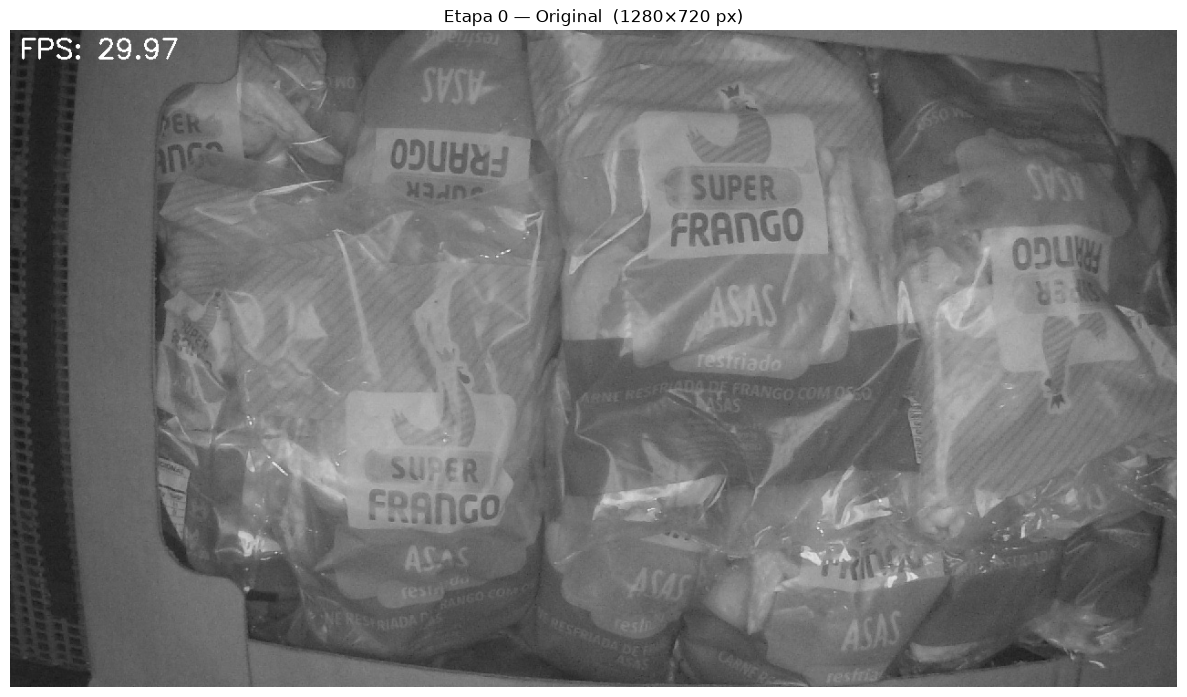

In [116]:
# --- Etapa 0: Carrega imagem de teste ---
#IMG_TESTE = os.path.join(BASE_DIR, 'Train_and_Validation/93000106_Coxas_e_Sobrecoxas_Congelado','TesteTempoPosicao2023-03-02 10_04_14.988946.jpg')
IMG_TESTE = os.path.join(BASE_DIR, 'Train_and_Validation/93000003_Asas_Resfriado_Selado','TesteTempoPosicao2025-02-05 14_17_15.653848.jpg')

img_orig = ler_imagem(IMG_TESTE)
h_img, w_img = img_orig.shape[:2]

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.title(f'Etapa 0 — Original  ({w_img}×{h_img} px)')
plt.axis('off')
plt.tight_layout()
plt.show()

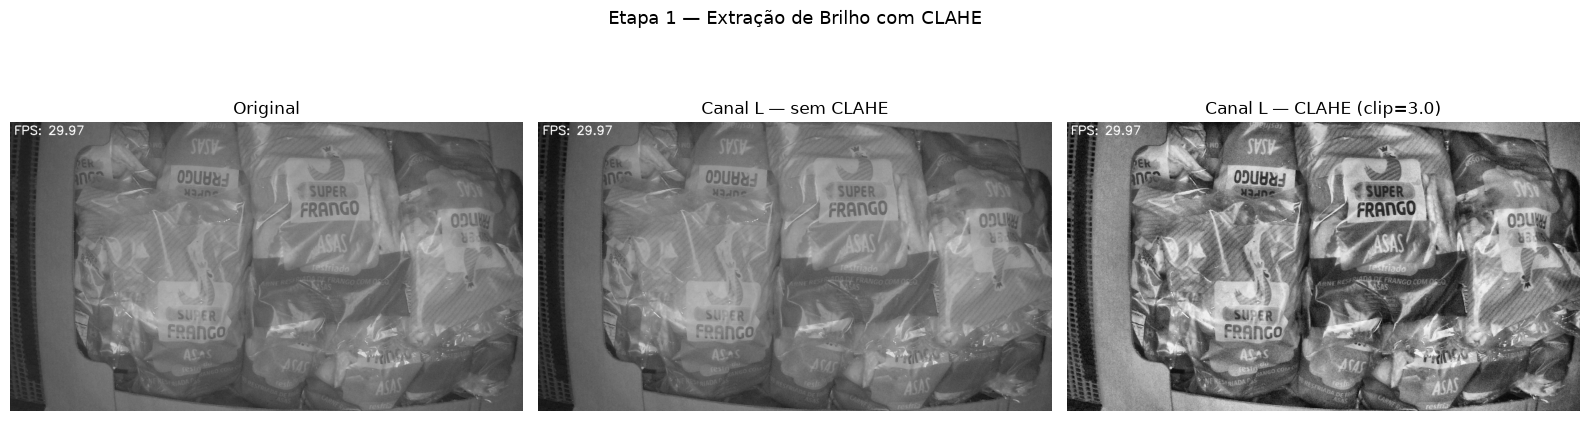

In [117]:
# --- Etapa 1: CLAHE no canal L (LAB) ---
l_eq = extrair_brilho(img_orig)

# canal L sem CLAHE (para comparação)
lab_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2LAB)
l_orig, _, _ = cv2.split(lab_orig)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[1].imshow(l_orig, cmap='gray')
axes[1].set_title('Canal L — sem CLAHE')
axes[2].imshow(l_eq, cmap='gray')
axes[2].set_title(f'Canal L — CLAHE (clip={CFG["clahe_clip"]})')
for ax in axes:
    ax.axis('off')
plt.suptitle('Etapa 1 — Extração de Brilho com CLAHE', fontsize=13)
plt.tight_layout()
plt.show()

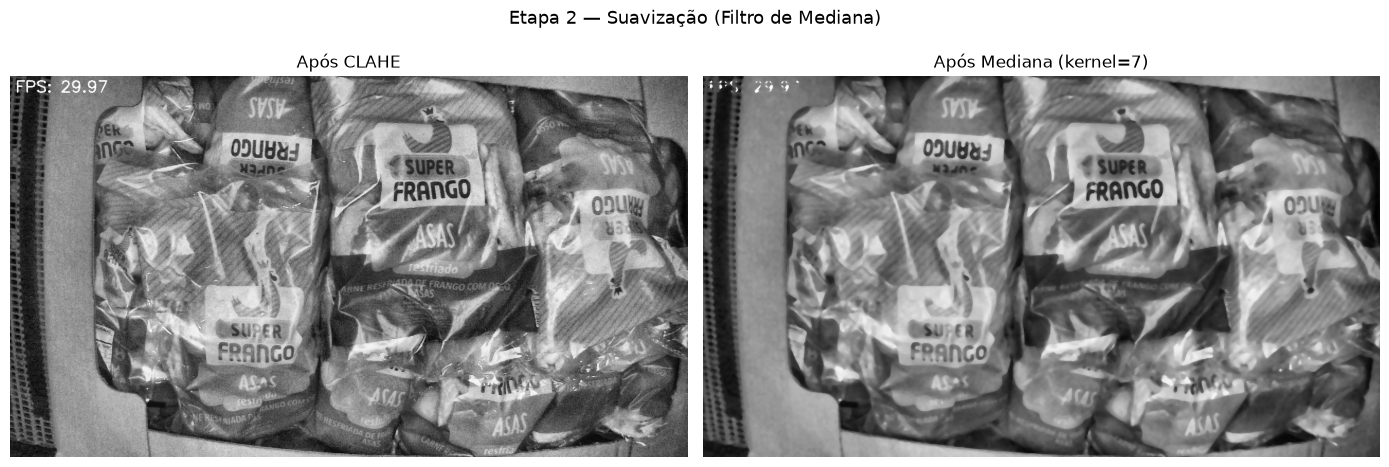

In [118]:
# --- Etapa 2: Suavização por Mediana ---
suave = suavizar(l_eq)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(l_eq, cmap='gray')
axes[0].set_title('Após CLAHE')
axes[1].imshow(suave, cmap='gray')
axes[1].set_title(f'Após Mediana (kernel={CFG["median_ksize"]})')
for ax in axes:
    ax.axis('off')
plt.suptitle('Etapa 2 — Suavização (Filtro de Mediana)', fontsize=13)
plt.tight_layout()
plt.show()

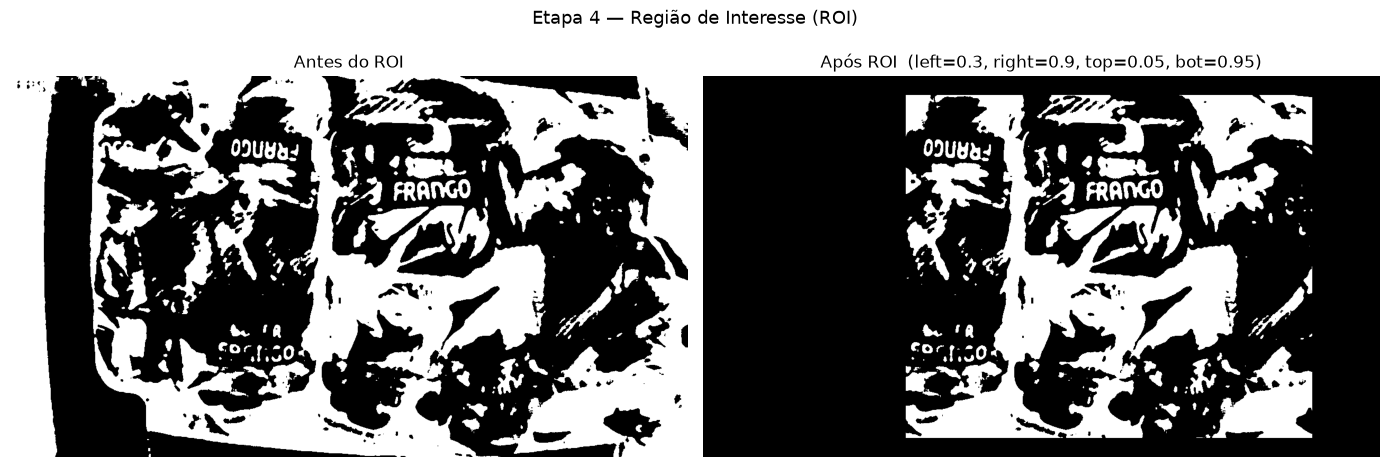

In [120]:
# --- Etapa 4: Máscara de ROI ---
# Remove bordas da imagem onde ficam esteira e paredes
binaria_roi = aplicar_roi(binaria, img_orig.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(binaria, cmap='gray')
axes[0].set_title('Antes do ROI')
axes[1].imshow(binaria_roi, cmap='gray')
axes[1].set_title(
    f'Após ROI  (left={CFG["roi_left"]}, right={CFG["roi_right"]}, '
    f'top={CFG["roi_top"]}, bot={CFG["roi_bot"]})')
for ax in axes:
    ax.axis('off')
plt.suptitle('Etapa 4 — Região de Interesse (ROI)', fontsize=13)
plt.tight_layout()
plt.show()

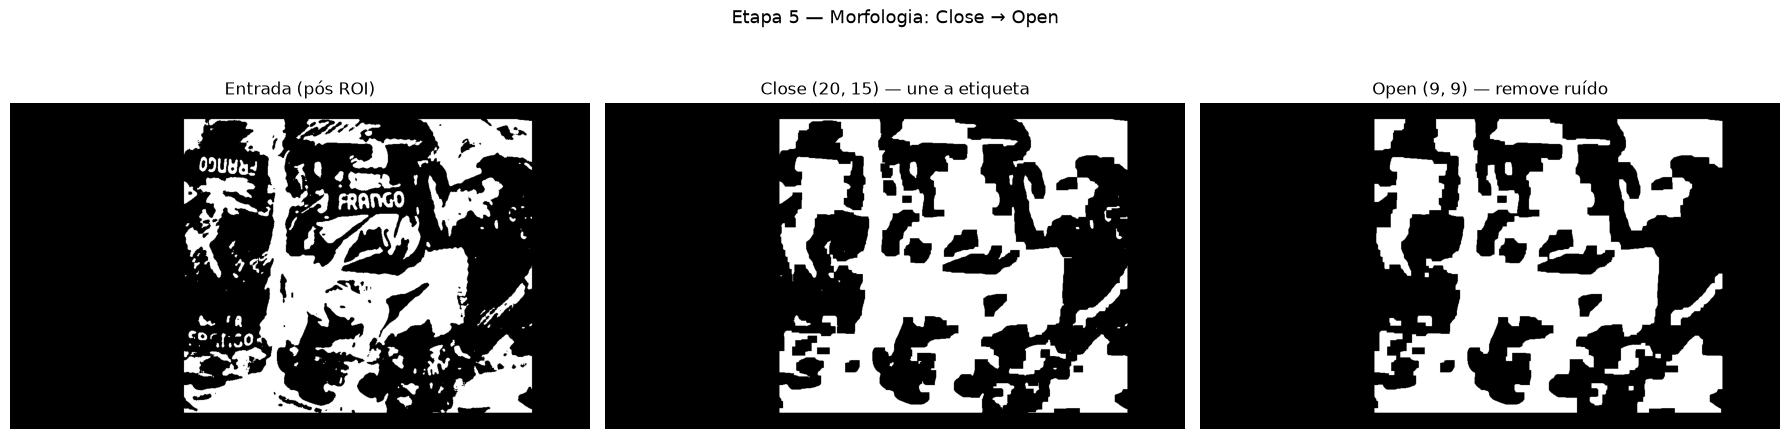

In [121]:
# --- Etapa 5: Morfologia (Close + Open) ---
k_close = cv2.getStructuringElement(cv2.MORPH_RECT, CFG["morph_close_ksize"])
k_open  = cv2.getStructuringElement(cv2.MORPH_RECT, CFG["morph_open_ksize"])

apos_close = cv2.morphologyEx(binaria_roi, cv2.MORPH_CLOSE, k_close)
mascara    = cv2.morphologyEx(apos_close,  cv2.MORPH_OPEN,  k_open)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(binaria_roi, cmap='gray')
axes[0].set_title('Entrada (pós ROI)')
axes[1].imshow(apos_close, cmap='gray')
axes[1].set_title(f'Close {CFG["morph_close_ksize"]} — une a etiqueta')
axes[2].imshow(mascara, cmap='gray')
axes[2].set_title(f'Open {CFG["morph_open_ksize"]} — remove ruído')
for ax in axes:
    ax.axis('off')
plt.suptitle('Etapa 5 — Morfologia: Close → Open', fontsize=13)
plt.tight_layout()
plt.show()

Total de blobs encontrados: 13

#    area       pos (x,y)      w x h          aspect   solidity   % img
----------------------------------------------------------------------
1    24961      (996,49)          109x229      0.48     0.66       2.7%
2    21582      (1033,441)          99x218      0.45     0.89       2.3%
3    19680      (809,36)          60x328      0.18     0.49       2.1%
4    14454      (433,468)          99x146      0.68     0.80       1.6%
5    13328      (431,315)          112x119      0.94     0.47       1.4%
6    13113      (904,328)          141x93       1.52     0.80       1.4%
7    8160       (432,36)          96x85       1.13     0.85       0.9%
8    7470       (809,435)          30x249      0.12     0.88       0.8%
9    752        (430,135)          16x47       0.34     0.96       0.1%
10   576        (751,561)          18x32       0.56     0.93       0.1%
11   540        (572,325)          36x15       2.40     0.94       0.1%
12   121        (726,108)       

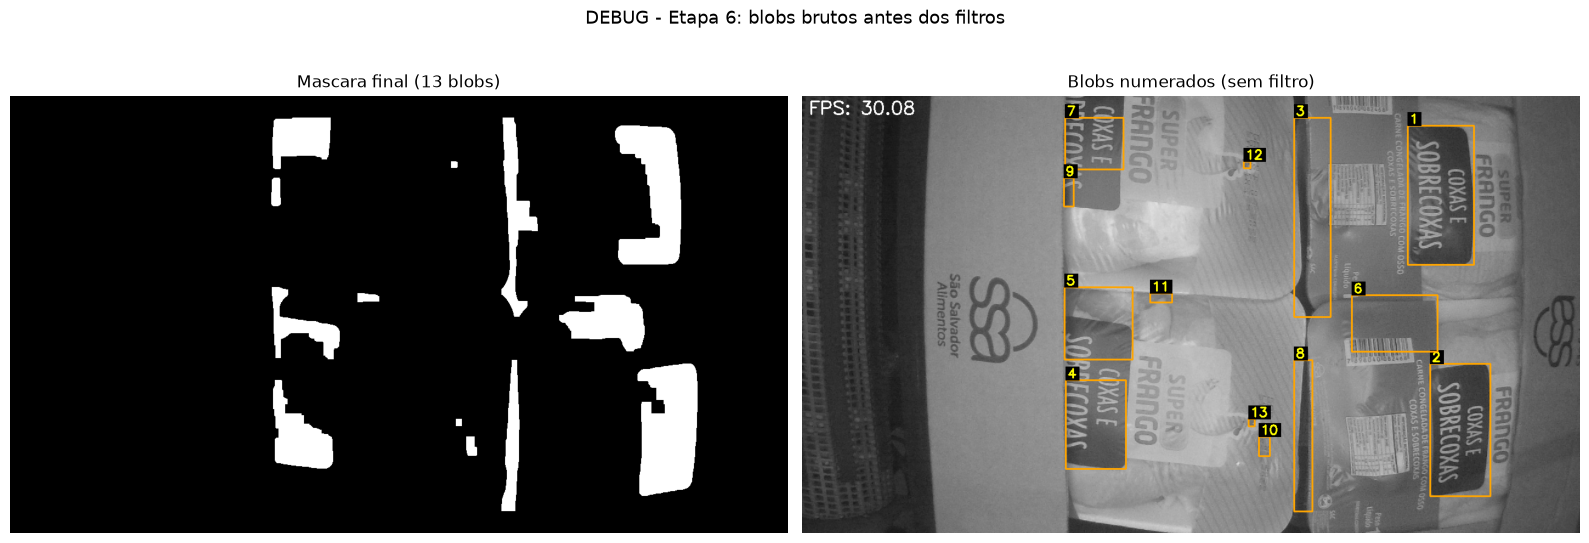

In [110]:
# --- DEBUG: todos os blobs antes de qualquer filtro ---
contornos_raw, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print("Total de blobs encontrados:", len(contornos_raw))
print()

area_total_img = h_img * w_img
dados_blobs = []
for cnt in contornos_raw:
    x, y, w, h = cv2.boundingRect(cnt)
    if h == 0 or w == 0: continue
    area_bbox = w * h
    area_cnt  = cv2.contourArea(cnt)
    aspect    = w / h
    hull      = cv2.convexHull(cnt)
    area_hull = cv2.contourArea(hull)
    solidity  = area_cnt / area_hull if area_hull > 0 else 0
    dados_blobs.append((area_bbox, x, y, w, h, aspect, solidity))

dados_blobs.sort(reverse=True)

print("{:<4} {:<10} {:<14} {:<14} {:<8} {:<10} {}".format(
    "#", "area", "pos (x,y)", "w x h", "aspect", "solidity", "% img"))
print("-" * 70)
for i, (ab, x, y, w, h, asp, sol) in enumerate(dados_blobs, 1):
    pct = ab * 100 / area_total_img
    print("{:<4} {:<10} ({},{}) {:<8} {}x{:<8} {:<8.2f} {:<10.2f} {:.1f}%".format(
        i, ab, x, y, "", w, h, asp, sol, pct))

# visual: todos os blobs com numero
debug_img = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB).copy()
for i, (ab, x, y, w, h, asp, sol) in enumerate(dados_blobs, 1):
    cv2.rectangle(debug_img, (x, y), (x+w, y+h), (255, 165, 0), 2)
    # fundo preto para o numero ficar legivel
    label = str(i)
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    cv2.rectangle(debug_img, (x, y - th - 6), (x + tw + 6, y), (0, 0, 0), -1)
    cv2.putText(debug_img, label, (x + 3, y - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(mascara, cmap="gray")
axes[0].set_title("Mascara final (" + str(len(contornos_raw)) + " blobs)")
axes[1].imshow(debug_img)
axes[1].set_title("Blobs numerados (sem filtro)")
for ax in axes: ax.axis("off")
plt.suptitle("DEBUG - Etapa 6: blobs brutos antes dos filtros", fontsize=13)
plt.tight_layout()
plt.show()

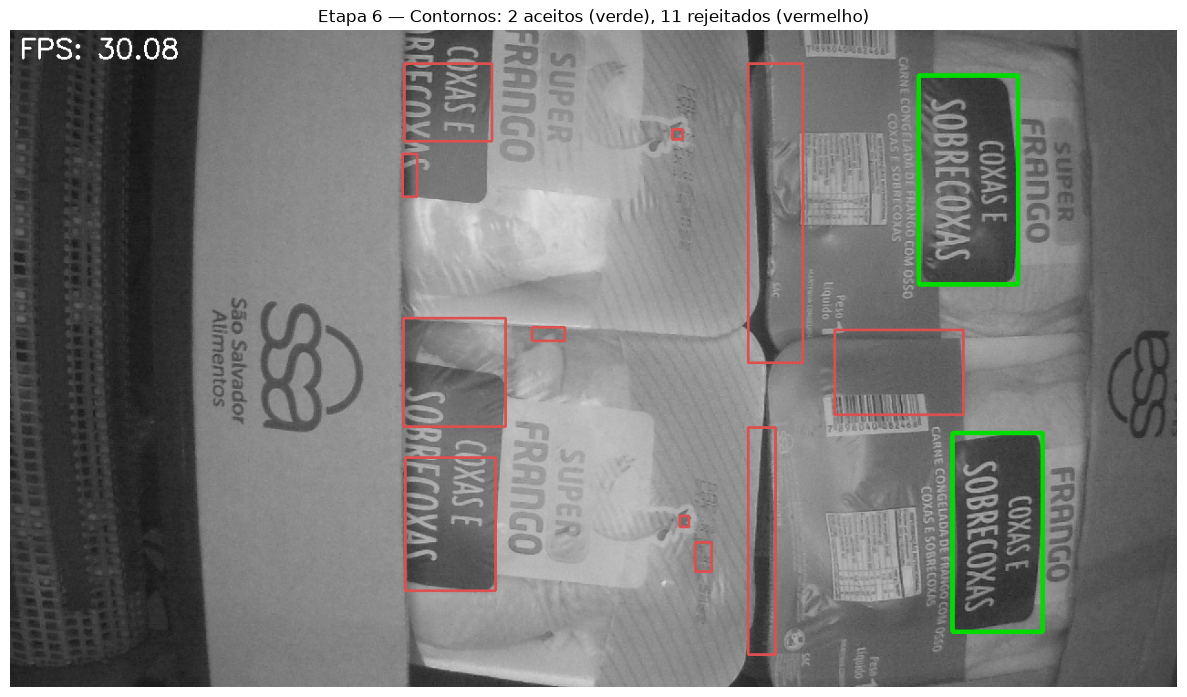


Aceitos (2):
  [1] (1033,441)  99×218px  aspect=0.45  2.3% da imagem
  [2] (996,49)  109×229px  aspect=0.48  2.7% da imagem

Rejeitados (11) — primeiros 8:
  ✗ (751,561) 18×32px → área 576 < 12000
  ✗ (734,532) 10×12px → área 120 < 12000
  ✗ (433,468) 99×146px → altura 146 < 150px
  ✗ (809,435) 30×249px → área 7470 < 12000
  ✗ (904,328) 141×93px → aspect 1.52 > 0.9
  ✗ (572,325) 36×15px → área 540 < 12000
  ✗ (431,315) 112×119px → aspect 0.94 > 0.9
  ✗ (430,135) 16×47px → área 752 < 12000


In [111]:
# --- Etapa 6: Contornos + filtros geométricos ---
area_total = h_img * w_img
contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

aceitos   = []
rejeitados = []

for cnt in contornos:
    x, y, w, h = cv2.boundingRect(cnt)
    if h == 0 or w == 0:
        continue
    area_bbox = w * h
    area_cnt  = cv2.contourArea(cnt)
    aspect    = w / h
    hull      = cv2.convexHull(cnt)
    area_hull = cv2.contourArea(hull)
    solidity  = area_cnt / area_hull if area_hull > 0 else 0

    motivo = None
    if   area_bbox < CFG["min_area"]:                    motivo = f'área {area_bbox} < {CFG["min_area"]}'
    elif area_bbox > area_total*CFG["max_area_ratio"]:   motivo = f'área {area_bbox/area_total:.1%} > {CFG["max_area_ratio"]:.0%}'
    elif aspect    < CFG["min_aspect"]:                  motivo = f'aspect {aspect:.2f} < {CFG["min_aspect"]}'
    elif aspect    > CFG["max_aspect"]:                  motivo = f'aspect {aspect:.2f} > {CFG["max_aspect"]}'
    elif h         < CFG["min_height_px"]:               motivo = f'altura {h} < {CFG["min_height_px"]}px'
    elif solidity  < CFG["min_solidity"]:                motivo = f'solidity {solidity:.2f} < {CFG["min_solidity"]}'

    if motivo:
        rejeitados.append((x, y, w, h, motivo))
    else:
        aceitos.append((x, y, w, h))

anotada = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB).copy()
for (x, y, w, h, _) in rejeitados:
    cv2.rectangle(anotada, (x, y), (x+w, y+h), (220, 80, 80), 2)
for (x, y, w, h) in aceitos:
    cv2.rectangle(anotada, (x, y), (x+w, y+h), (0, 220, 0), 4)

plt.figure(figsize=(12, 7))
plt.imshow(anotada)
plt.title(f'Etapa 6 — Contornos: {len(aceitos)} aceitos (verde), {len(rejeitados)} rejeitados (vermelho)')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'\nAceitos ({len(aceitos)}):')
for i, (x, y, w, h) in enumerate(aceitos, 1):
    print(f'  [{i}] ({x},{y})  {w}×{h}px  aspect={w/h:.2f}  {w*h*100/area_total:.1f}% da imagem')

print(f'\nRejeitados ({len(rejeitados)}) — primeiros 8:')
for x, y, w, h, m in rejeitados[:8]:
    print(f'  ✗ ({x},{y}) {w}×{h}px → {m}')

Antes do NMS: 2 regiões
Após  o NMS: 2 regiões



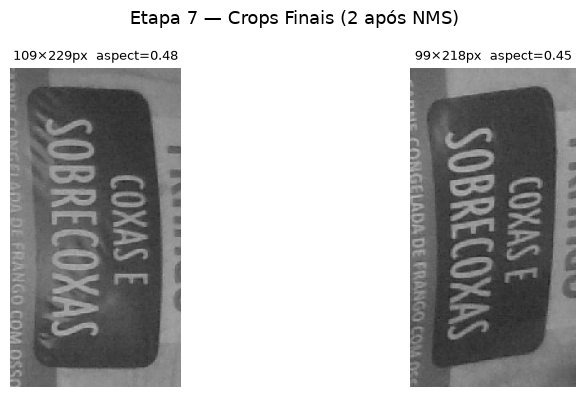

In [112]:
# --- Etapa 7: NMS + crops finais ---
regioes_finais = nms(aceitos)
pad = CFG["padding"]

print(f'Antes do NMS: {len(aceitos)} regiões')
print(f'Após  o NMS: {len(regioes_finais)} regiões\n')

if regioes_finais:
    cols = min(len(regioes_finais), 4)
    rows = (len(regioes_finais) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes_flat = np.array(axes).flatten()
    for ax, (x, y, w, h) in zip(axes_flat, regioes_finais):
        x1 = max(0, x-pad);       y1 = max(0, y-pad)
        x2 = min(w_img, x+w+pad); y2 = min(h_img, y+h+pad)
        crop = cv2.cvtColor(img_orig[y1:y2, x1:x2], cv2.COLOR_BGR2RGB)
        ax.imshow(crop)
        ax.set_title(f'{w}×{h}px  aspect={w/h:.2f}', fontsize=9)
        ax.axis('off')
    for ax in axes_flat[len(regioes_finais):]:
        ax.axis('off')
    plt.suptitle(f'Etapa 7 — Crops Finais ({len(regioes_finais)} após NMS)', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('Nenhuma região detectada. Ajuste os parâmetros no CFG (seção 4).')

In [113]:
# --- Teste: processa apenas a classe Coxas_e_Sobrecoxas_Congelado ---
import shutil

CLASSE_TESTE = "93000106_Coxas_e_Sobrecoxas_Congelado"
pasta_classe  = os.path.join(INPUT_ROOT, CLASSE_TESTE)
pasta_saida   = os.path.join(OUTPUT_ROOT, CLASSE_TESTE)

# limpa resultados anteriores da classe
if os.path.exists(pasta_saida):
    shutil.rmtree(pasta_saida)
    print("Pasta de saida limpa:", pasta_saida)

EXTENSOES = ("*.jpg", "*.jpeg", "*.png", "*.bmp")
arquivos = []
for ext in EXTENSOES:
    arquivos.extend(glob.glob(os.path.join(pasta_classe, ext)))
    arquivos.extend(glob.glob(os.path.join(pasta_classe, ext.upper())))
arquivos = sorted(set(arquivos))

print("Classe  :", CLASSE_TESTE)
print("Imagens :", len(arquivos))
print("Saida   :", pasta_saida)
print()

total_crops = 0
sem_deteccao = []

for caminho in arquivos:
    nome_arquivo = os.path.basename(caminho)
    nome_sem_ext = os.path.splitext(nome_arquivo)[0]
    saida_base   = os.path.join(pasta_saida, nome_sem_ext)
    try:
        n = processar_imagem(caminho, saida_base)
        if n > 0:
            print("  [OK] " + nome_arquivo + " -> " + str(n) + " crop(s)")
            total_crops += n
        else:
            print("  [--] " + nome_arquivo + " -> SEM DETECCAO")
            sem_deteccao.append(nome_arquivo)
    except Exception as exc:
        print("  [ERRO] " + nome_arquivo + " -> " + str(exc))

print()
print("=" * 50)
print("Total:", len(arquivos), "imagens |", total_crops, "crops salvos")
print("Sem deteccao:", len(sem_deteccao), "/", len(arquivos))
if sem_deteccao:
    print()
    print("Imagens sem deteccao:")
    for nome in sem_deteccao:
        print("  -", nome)

Pasta de saida limpa: e:\Users\Downloads\pdi-trabalho\resultado\93000106_Coxas_e_Sobrecoxas_Congelado
Classe  : 93000106_Coxas_e_Sobrecoxas_Congelado
Imagens : 50
Saida   : e:\Users\Downloads\pdi-trabalho\resultado\93000106_Coxas_e_Sobrecoxas_Congelado

  [OK] TesteTempoPosicao2023-03-02 10_03_45.097032.jpg -> 3 crop(s)
  [OK] TesteTempoPosicao2023-03-02 10_04_14.988946.jpg -> 2 crop(s)
  [OK] TesteTempoPosicao2023-03-02 10_04_38.053771.jpg -> 3 crop(s)
  [OK] TesteTempoPosicao2023-03-02 10_05_25.175178.jpg -> 3 crop(s)
  [OK] TesteTempoPosicao2023-03-02 10_05_57.571153.jpg -> 2 crop(s)
  [OK] TesteTempoPosicao2023-03-02 10_07_01.956482.jpg -> 3 crop(s)
  [OK] TesteTempoPosicao2023-03-02 10_09_34.225984.jpg -> 3 crop(s)
  [OK] TesteTempoPosicao2023-03-02 10_09_57.885732.jpg -> 2 crop(s)
  [OK] TesteTempoPosicao2023-03-02 10_10_19.949661.jpg -> 1 crop(s)
  [OK] TesteTempoPosicao2023-03-02 10_10_49.010453.jpg -> 1 crop(s)
  [OK] TesteTempoPosicao2023-03-02 10_11_01.772662.jpg -> 3 crop(s

## 7. Processar o dataset completo
Rode esta célula apenas após validar o pipeline na seção 6.

In [88]:
import shutil

# limpa toda a pasta de resultados antes de processar
if os.path.exists(OUTPUT_ROOT):
    shutil.rmtree(OUTPUT_ROOT)
    print("Resultados anteriores apagados:", OUTPUT_ROOT)

EXTENSOES = ("*.jpg", "*.jpeg", "*.png", "*.bmp")

total_imgs  = 0
total_crops = 0

for classe_entry in sorted(os.scandir(INPUT_ROOT), key=lambda e: e.name):
    if not classe_entry.is_dir():
        continue
    nome_classe = classe_entry.name

    arquivos = []
    for ext in EXTENSOES:
        arquivos.extend(glob.glob(os.path.join(classe_entry.path, ext)))
        arquivos.extend(glob.glob(os.path.join(classe_entry.path, ext.upper())))
    arquivos = sorted(set(arquivos))

    if not arquivos:
        print("[INFO] " + nome_classe + " sem imagens - ignorada.")
        continue

    print("")
    print("[CLASSE] " + nome_classe + " - " + str(len(arquivos)) + " imagens")

    for caminho in arquivos:
        nome_sem_ext = os.path.splitext(os.path.basename(caminho))[0]
        saida_base   = os.path.join(OUTPUT_ROOT, nome_classe, nome_sem_ext)
        try:
            n = processar_imagem(caminho, saida_base)
            print("  OK " + os.path.basename(caminho) + " -> " + str(n) + " crop(s)")
            total_imgs  += 1
            total_crops += n
        except Exception as exc:
            print("  ERRO: " + str(exc))

print()
print("=" * 50)
print("Total:", total_imgs, "imagens |", total_crops, "crops salvos em", OUTPUT_ROOT)


Resultados anteriores apagados: e:\Users\Downloads\pdi-trabalho\resultado

[CLASSE] 93000003_Asas_Resfriado_Selado - 50 imagens
  OK TesteTempoPosicao2025-02-05 14_14_11.524118.jpg -> 0 crop(s)
  OK TesteTempoPosicao2025-02-05 14_14_54.048772.jpg -> 1 crop(s)
  OK TesteTempoPosicao2025-02-05 14_15_31.807916.jpg -> 0 crop(s)
  OK TesteTempoPosicao2025-02-05 14_15_44.638655.jpg -> 0 crop(s)
  OK TesteTempoPosicao2025-02-05 14_15_46.937965.jpg -> 0 crop(s)
  OK TesteTempoPosicao2025-02-05 14_16_10.933489.jpg -> 0 crop(s)
  OK TesteTempoPosicao2025-02-05 14_17_15.653848.jpg -> 1 crop(s)
  OK TesteTempoPosicao2025-02-05 14_19_24.860769.jpg -> 1 crop(s)
  OK TesteTempoPosicao2025-02-05 14_20_04.321346.jpg -> 0 crop(s)
  OK TesteTempoPosicao2025-02-05 14_21_06.439144.jpg -> 1 crop(s)
  OK TesteTempoPosicao2025-02-05 14_22_47.353577.jpg -> 0 crop(s)
  OK TesteTempoPosicao2025-02-05 14_25_30.855608.jpg -> 1 crop(s)
  OK TesteTempoPosicao2025-02-05 14_25_43.518549.jpg -> 1 crop(s)
  OK TesteTemp

## 8. Visualizar crops gerados (amostra)

In [ ]:
crops_encontrados = glob.glob(os.path.join(OUTPUT_ROOT, '**', '*.png'), recursive=True)[:12]

if not crops_encontrados:
    print("Nenhum crop encontrado. Verifique OUTPUT_ROOT e rode a seção 7.")
else:
    cols = 4
    rows = (len(crops_encontrados) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
    for ax, path in zip(np.array(axes).flatten(), crops_encontrados):
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(os.path.basename(path), fontsize=7)
        ax.axis('off')
    for ax in np.array(axes).flatten()[len(crops_encontrados):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()